<a href="https://colab.research.google.com/github/diwashojha17/Ml-lab-works/blob/main/lab4kaggledataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Trees and Random Forest Classifier on diabetes dataset from kaggle

In [46]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
df = pd.read_csv('/content/drive/MyDrive/ML/dataset/diabetes.csv')

In [49]:
df=pd.DataFrame(df)
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [50]:
df=df.head()
print(df)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [51]:
df=df.describe()
print(df)

       Pregnancies     Glucose  BloodPressure  SkinThickness    Insulin  \
count     5.000000    5.000000       5.000000       5.000000    5.00000   
mean      3.200000  128.400000      61.600000      24.400000   52.40000   
std       3.563706   41.458413      12.441865      14.518953   76.37277   
min       0.000000   85.000000      40.000000       0.000000    0.00000   
25%       1.000000   89.000000      64.000000      23.000000    0.00000   
50%       1.000000  137.000000      66.000000      29.000000    0.00000   
75%       6.000000  148.000000      66.000000      35.000000   94.00000   
max       8.000000  183.000000      72.000000      35.000000  168.00000   

             BMI  DiabetesPedigreeFunction        Age   Outcome  
count   5.000000                  5.000000   5.000000  5.000000  
mean   30.940000                  0.821000  33.400000  0.600000  
std     7.749387                  0.845657  10.454664  0.547723  
min    23.300000                  0.167000  21.000000  0.000

In [52]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [60]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Train the DEcision tress classifier
model=DecisionTreeClassifier(criterion='entropy')
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

[Text(0.4849269701086957, 0.9705882352941176, 'Glucose <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]\nclass = 0'),
 Text(0.19132133152173914, 0.9117647058823529, 'Age <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]\nclass = 0'),
 Text(0.3381241508152174, 0.9411764705882353, 'True  '),
 Text(0.06793478260869565, 0.8529411764705882, 'BMI <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]\nclass = 0'),
 Text(0.021739130434782608, 0.7941176470588235, 'DiabetesPedigreeFunction <= 0.672\nentropy = 0.068\nsamples = 124\nvalue = [123, 1]\nclass = 0'),
 Text(0.010869565217391304, 0.7352941176470589, 'entropy = 0.0\nsamples = 108\nvalue = [108, 0]\nclass = 0'),
 Text(0.03260869565217391, 0.7352941176470589, 'DiabetesPedigreeFunction <= 0.686\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]\nclass = 0'),
 Text(0.021739130434782608, 0.6764705882352942, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1 '),
 Text(0.043478260869565216, 0.6764705882352942, 'entro

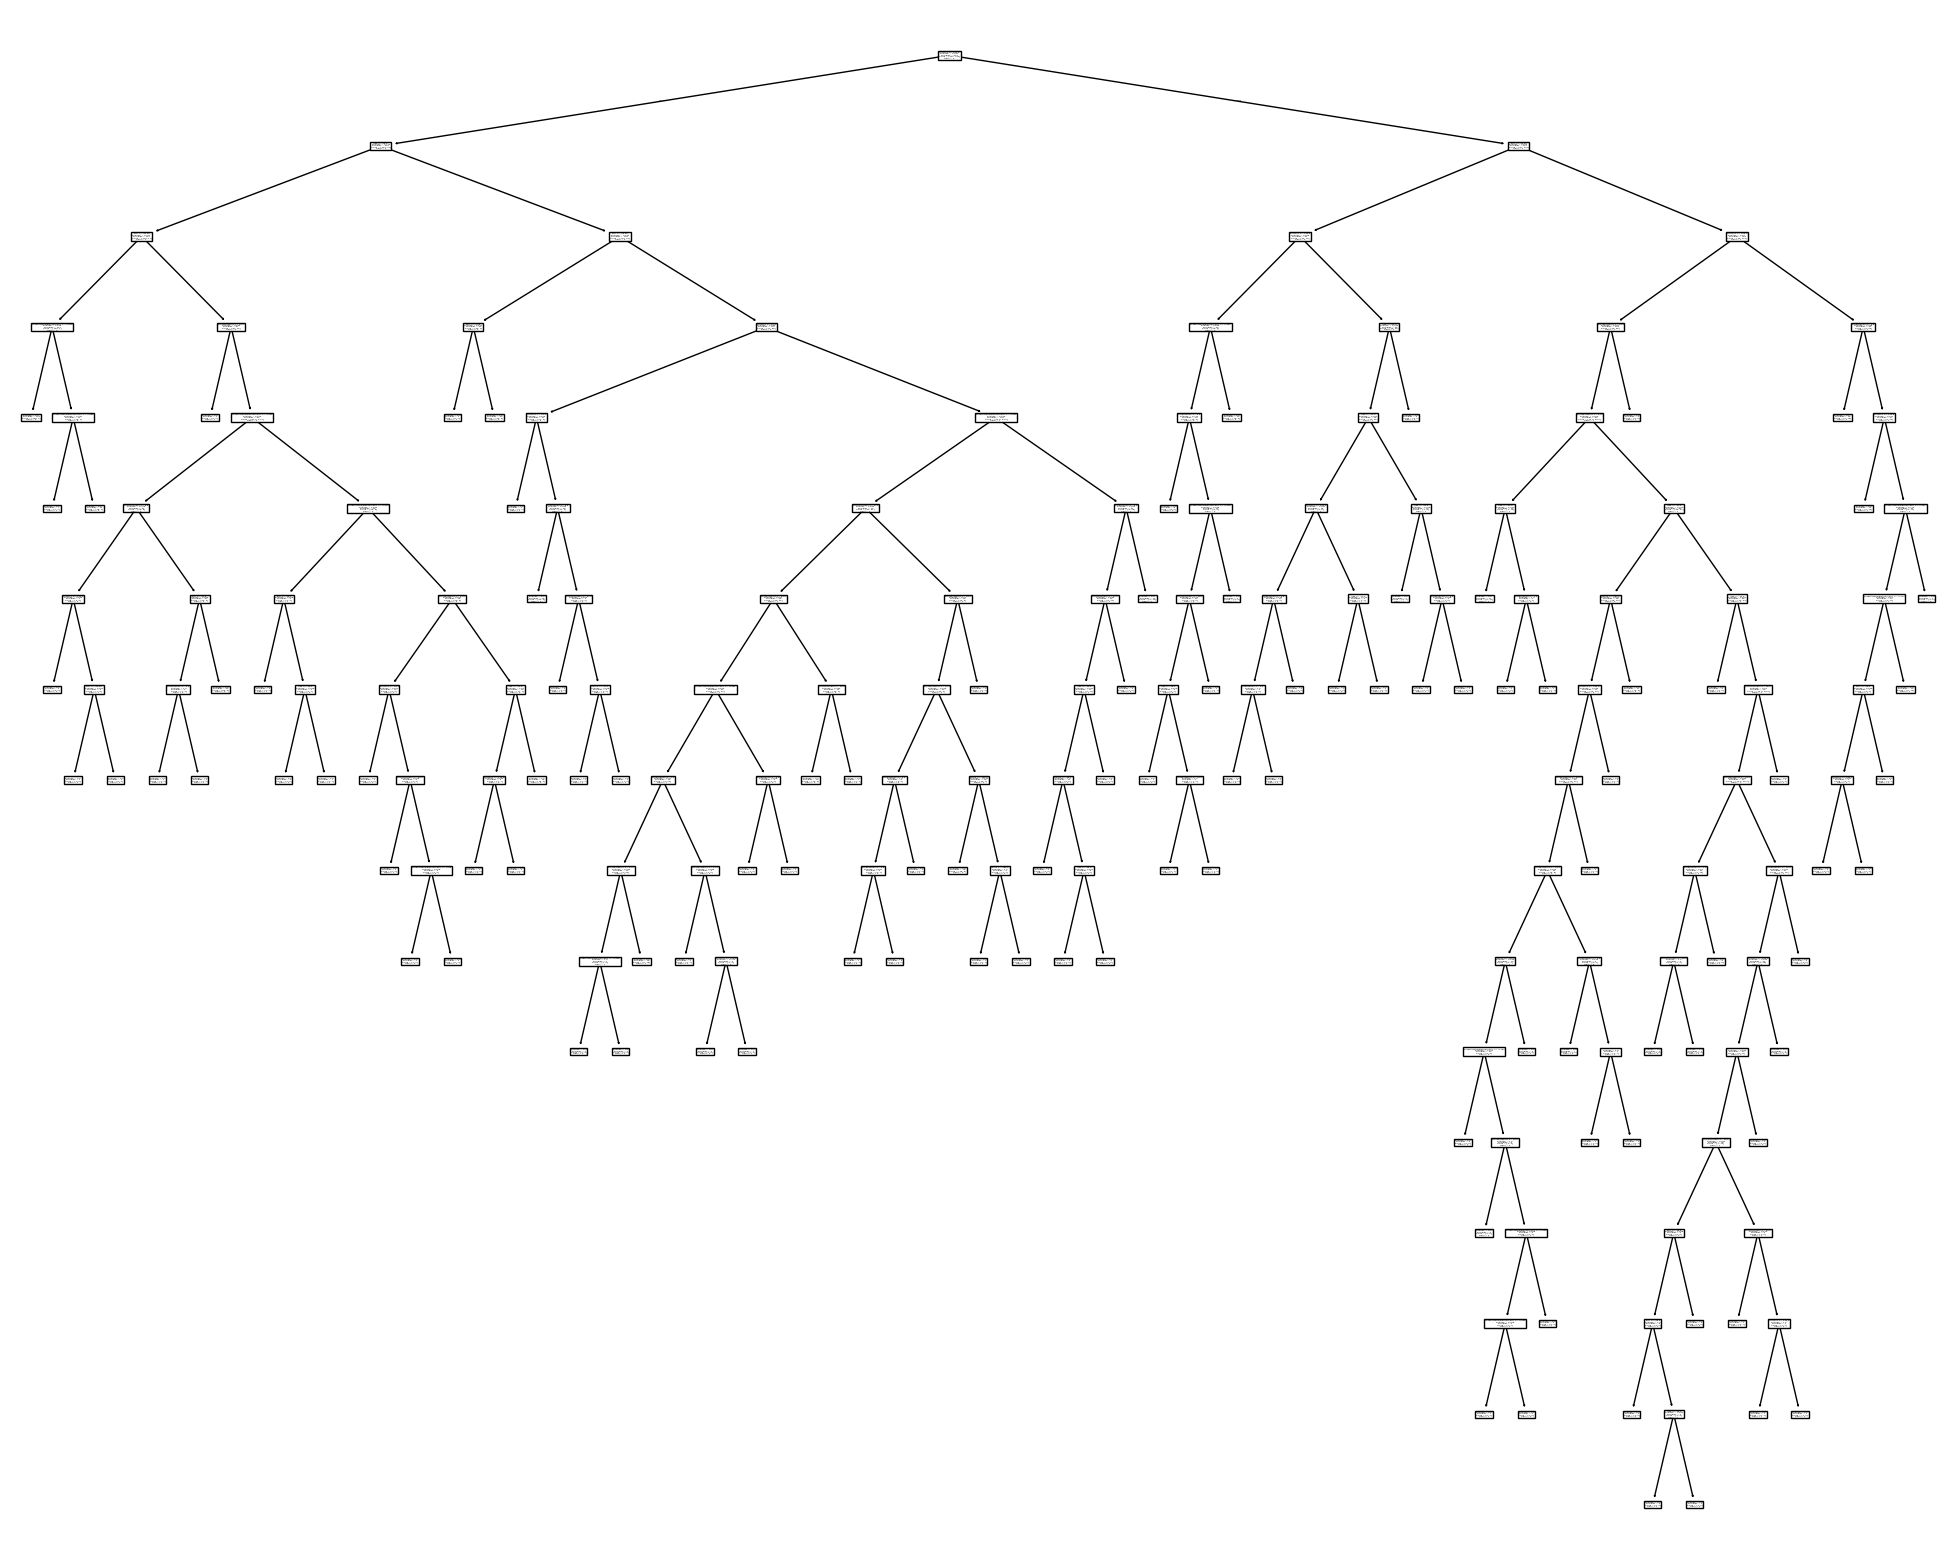

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(25,20))
plot_tree(model, feature_names=X.columns, class_names=['0','1 '])

In [62]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[75 24]
 [16 39]]
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.62      0.71      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.74      0.74       154



In [57]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=10,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [58]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[80 19]
 [17 38]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



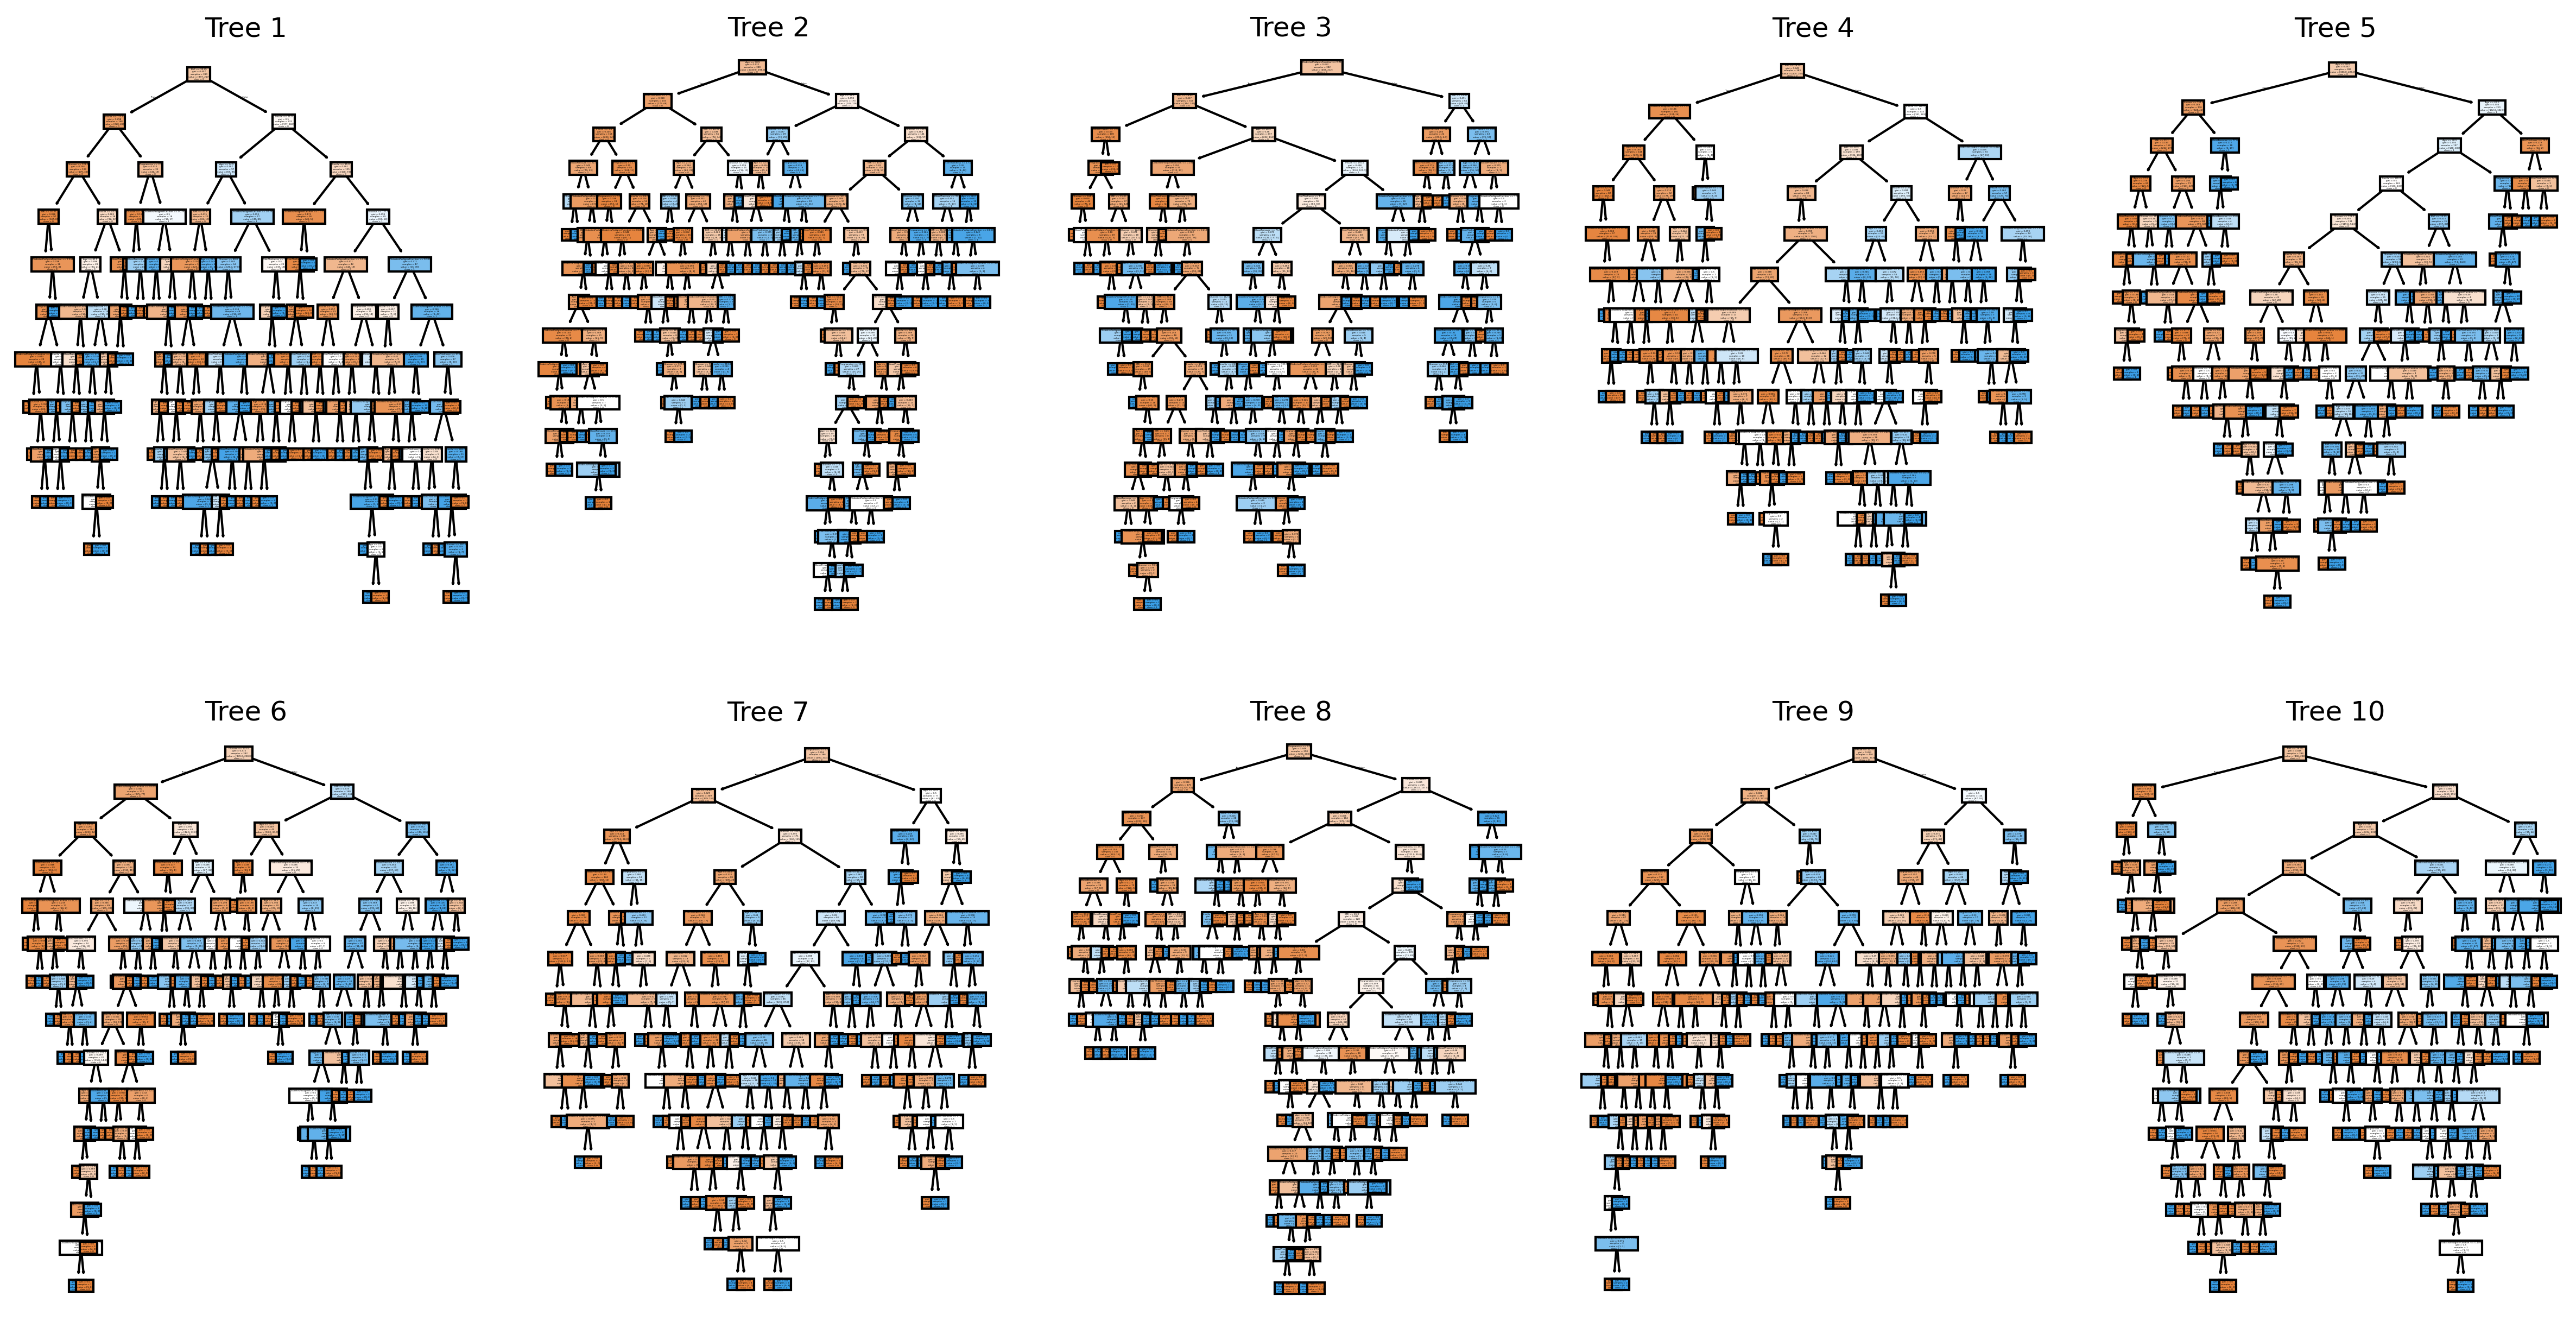

In [64]:
num_trees = len(model.estimators_)
cols = 5
rows = (num_trees + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 10), dpi=300)
axes = axes.flatten()
for i, tree in enumerate(model.estimators_):
    plot_tree(tree, feature_names=X.columns, class_names=['0', '1 '], filled=True, ax=axes[i])
    axes[i].set_title(f"Tree {i+1}")